In [1]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
from scipy.optimize import minimize
import scipy
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG, col_pc
from sklearn.model_selection import KFold

from scipy.linalg import subspace_angles
from scipy.stats import spearmanr
import nibabel as nib
from nilearn import datasets
from nilearn.image import load_img


In [2]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


In [4]:
out_path = 'out/data'

with open(out_path + '/ieeg_data_mean.p', "rb") as f:
    ieeg_data = pickle.load(f)

with open(out_path + '/data_matched.p', "rb") as f:
    data_matched = pickle.load(f)  

data_matched = data_matched.mean(0)
ieeg_data = ieeg_data.mean(0)

In [5]:
# Latent Space and Kmeans
df_label  =pd.read_csv('out/labels/labels_Kmean_singlePC3.csv').drop(columns = ['Unnamed: 0'])
df_label_meg  =pd.read_csv('out/labels/labels_Kmean_MEG_match_pc.csv').drop(columns = ['Unnamed: 0'])

## PCA only

In [6]:
pca_matched = PCA(10)
meg_match_trans = pca_matched.fit_transform(data_matched.T) 

pca_ieeg = PCA(10)
ieeg_trans = pca_ieeg.fit_transform(ieeg_data.T) 

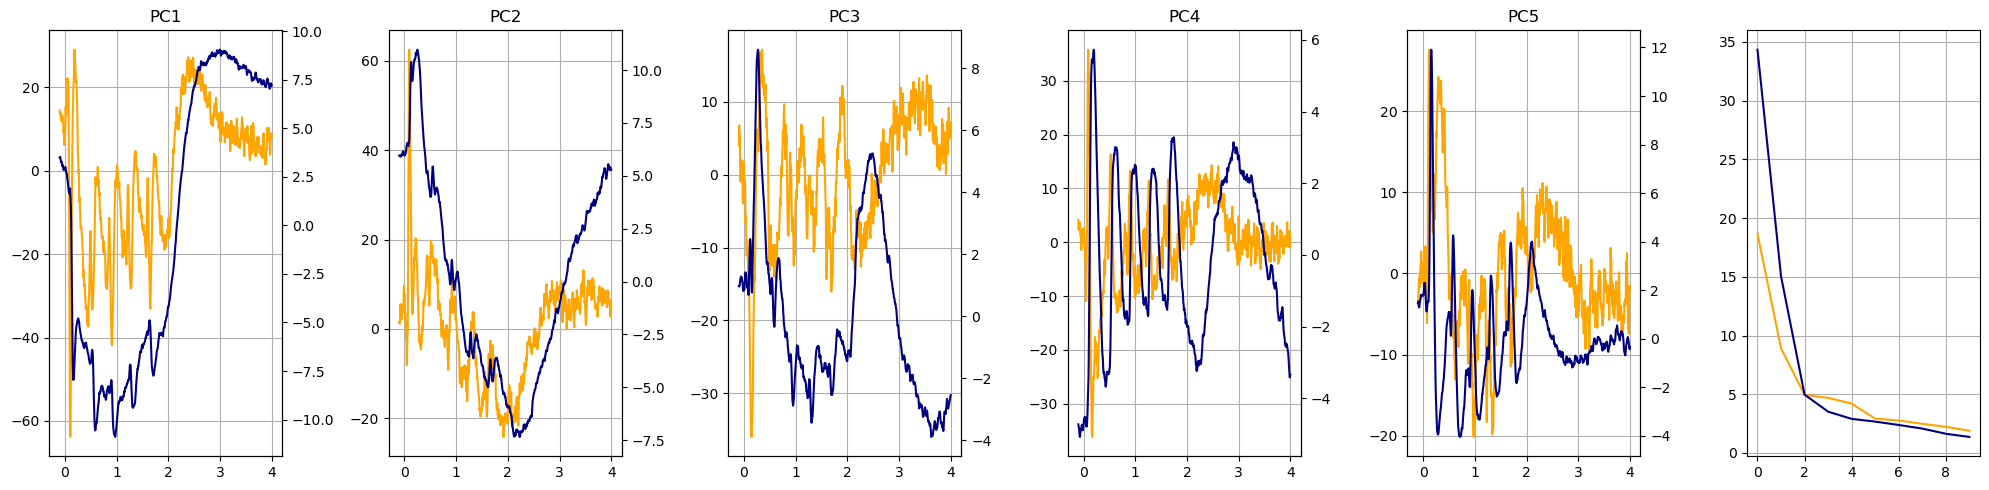

In [7]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 5))

for pc in range(5) :
    ax[pc].plot(time_ieeg, meg_match_trans[:, pc], c='orange', label='meg match')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, ieeg_trans[:, pc], c='navy',  label='ieeg')
    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))

ax[-1].plot(pca_matched.explained_variance_ratio_*100,  c='orange', label='meg match')
ax[-1].plot(pca_ieeg.explained_variance_ratio_*100,  c='navy',  label='ieeg')
ax[-1].grid()

fig.tight_layout()

In [8]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(pca_matched.components_[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})
    

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    
    
res_PCA= pd.DataFrame(res)

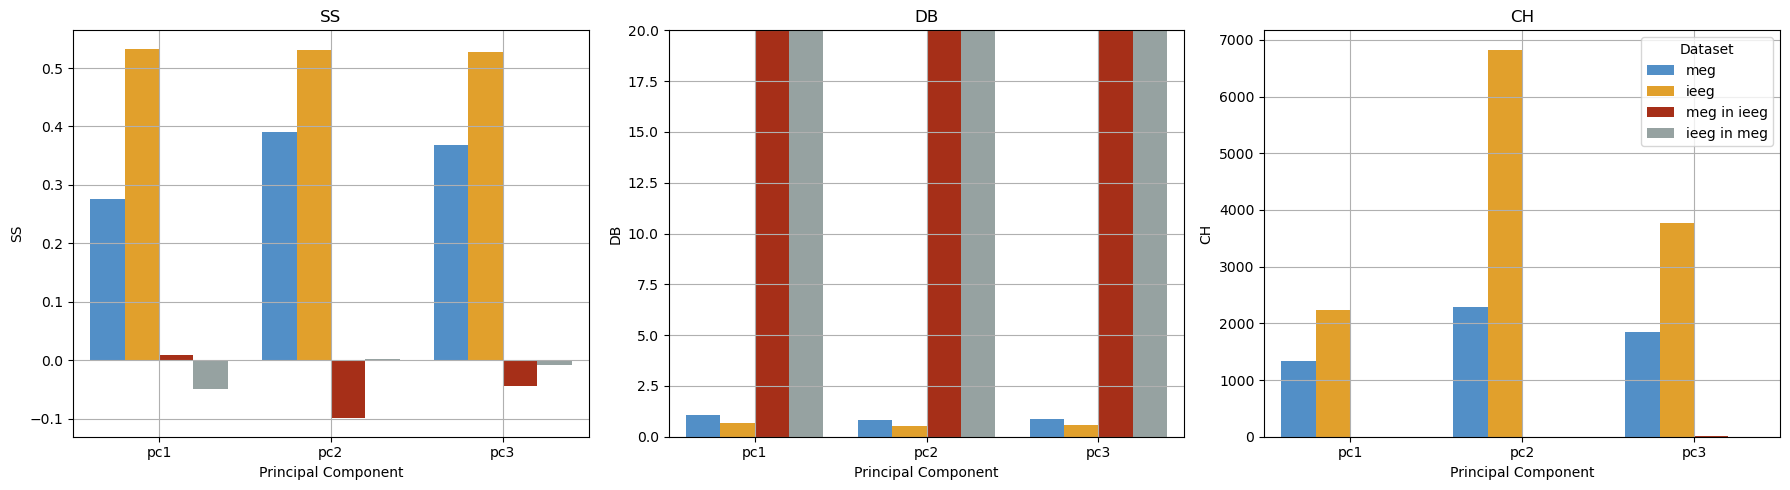

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=res_PCA,x='pc_lab',y=metric,hue='dataset',ax=ax)
    if metric == 'db' : ax.set_ylim(0, 20)
    
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

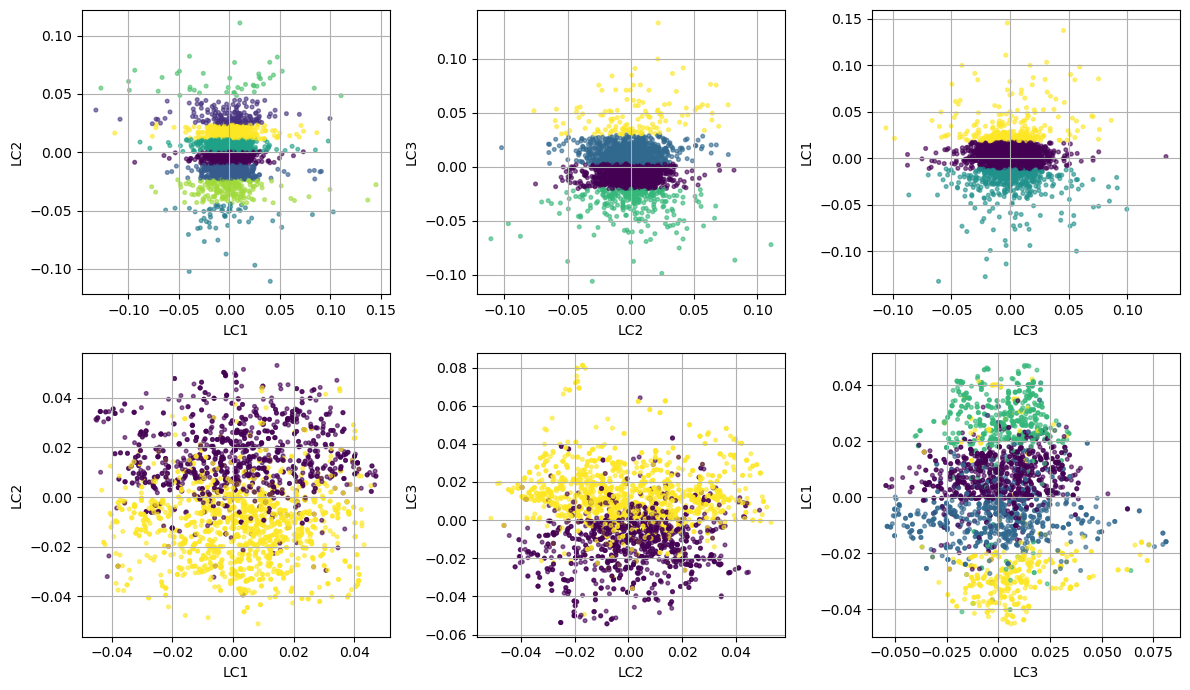

In [10]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()
for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(pca_ieeg.components_[i, :], pca_ieeg.components_[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(pca_matched.components_[i, :], pca_matched.components_[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

## PCA JOINT

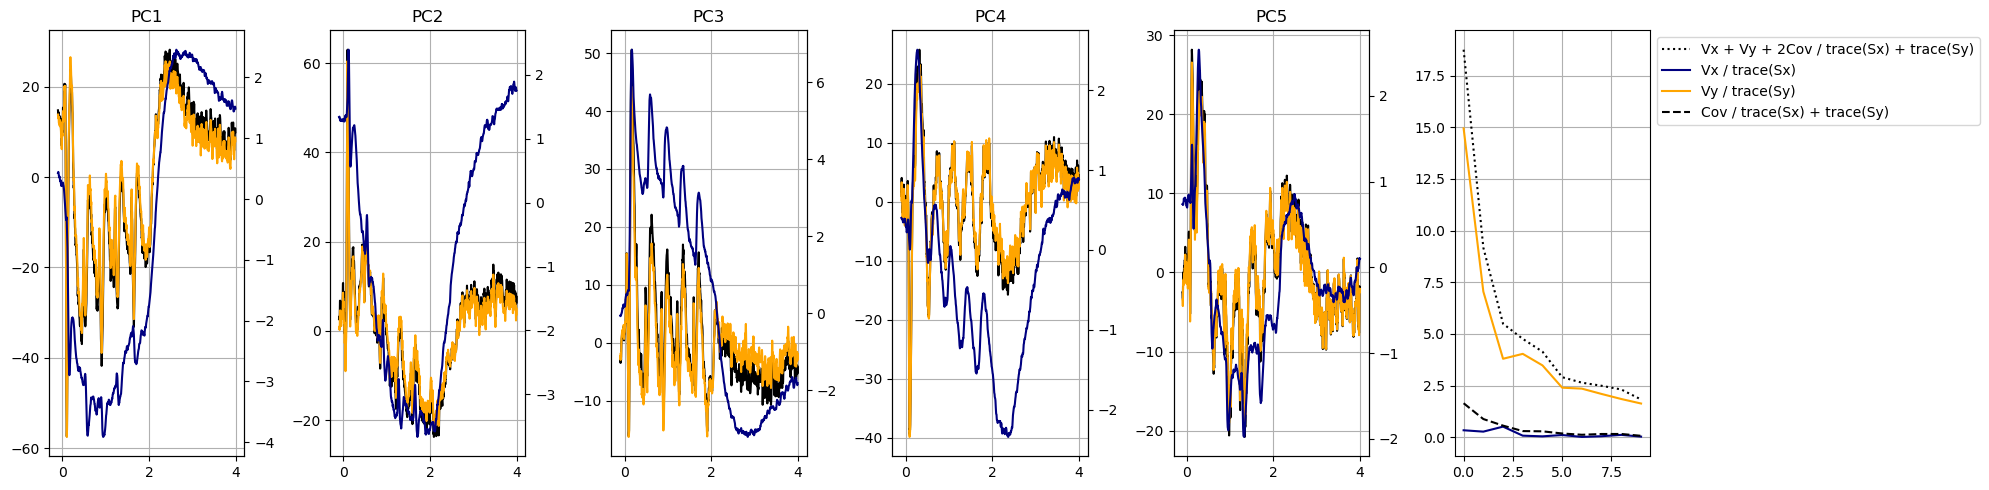

In [12]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 5))

for pc in range(5) :
    ax[pc].plot(time_ieeg, join_transform[:, pc], c='k', label='joint')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, X_trans.T[:, pc], c='navy', label='ieeg')
    ax[pc].plot(time_ieeg, Y_trans.T[:, pc], c='orange', label='meg')
    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))


ax[-1].plot(pca_join_.explained_variance_ratio_*100,  c='k',ls=':', label='Vx + Vy + 2Cov / trace(Sx) + trace(Sy)')
ax[-1].plot(varx_norm*100,  c='navy', label='Vx / trace(Sx)')
ax[-1].plot(vary_norm*100,  c='orange', label='Vy / trace(Sy)')
ax[-1].plot(cv_norm*100,  c='k',ls='--', label='Cov / trace(Sx) + trace(Sy)')
ax[-1].legend(bbox_to_anchor=(1, 1))
ax[-1].grid()

fig.tight_layout()

In [13]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})
    

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    
    
res_PCA_joint= pd.DataFrame(res)

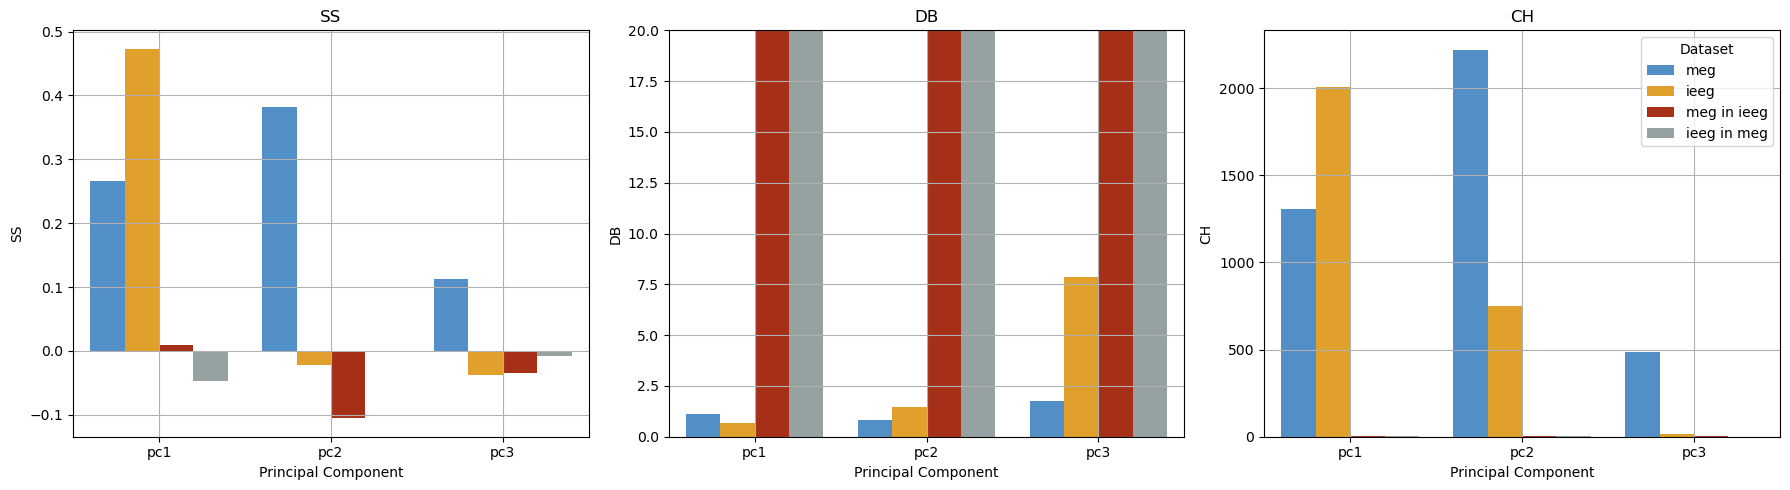

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PCA_joint,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()
    if metric == 'db' : ax.set_ylim(0, 20)

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

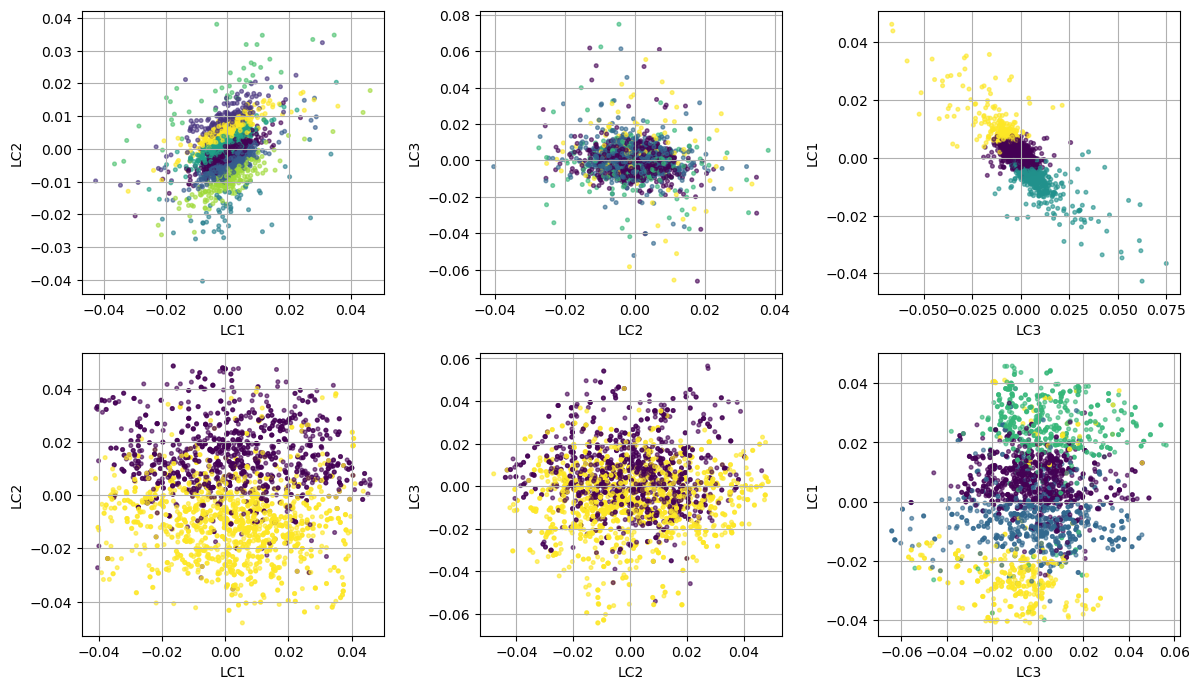

In [15]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(Wx[i, :], Wx[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(Wy[i, :], Wy[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

In [16]:
nb_compo=10
model='PLSSVD'
scaled_ = False

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_model.p'
with open(file, "rb") as f:
    cca_model = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_X.p'
with open(file, "rb") as f:
    Xcca = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_Y.p'
with open(file, "rb") as f:
    Ycca = pickle.load(f)

Wx = cca_model.x_weights_.T
Wy = cca_model.y_weights_.T

n_samples = ieeg_data.shape[1]

# Total variance
total_var = (np.sum(ieeg_data ** 2) +np.sum(data_matched ** 2)) / (n_samples - 1)
varx = np.diag(Wx @ ieeg_data @ ieeg_data.T @ Wx.T) / (n_samples - 1)
vary = np.diag(Wy @ data_matched @ data_matched.T @ Wy.T) / (n_samples - 1)
X_latent = Wx @ ieeg_data
Y_latent = Wy @ data_matched
cross = np.sum(X_latent * Y_latent,axis=1) / (n_samples - 1)
cv = cross
varx_norm = varx / total_var
vary_norm = vary / total_var
cv_norm = cv / total_var

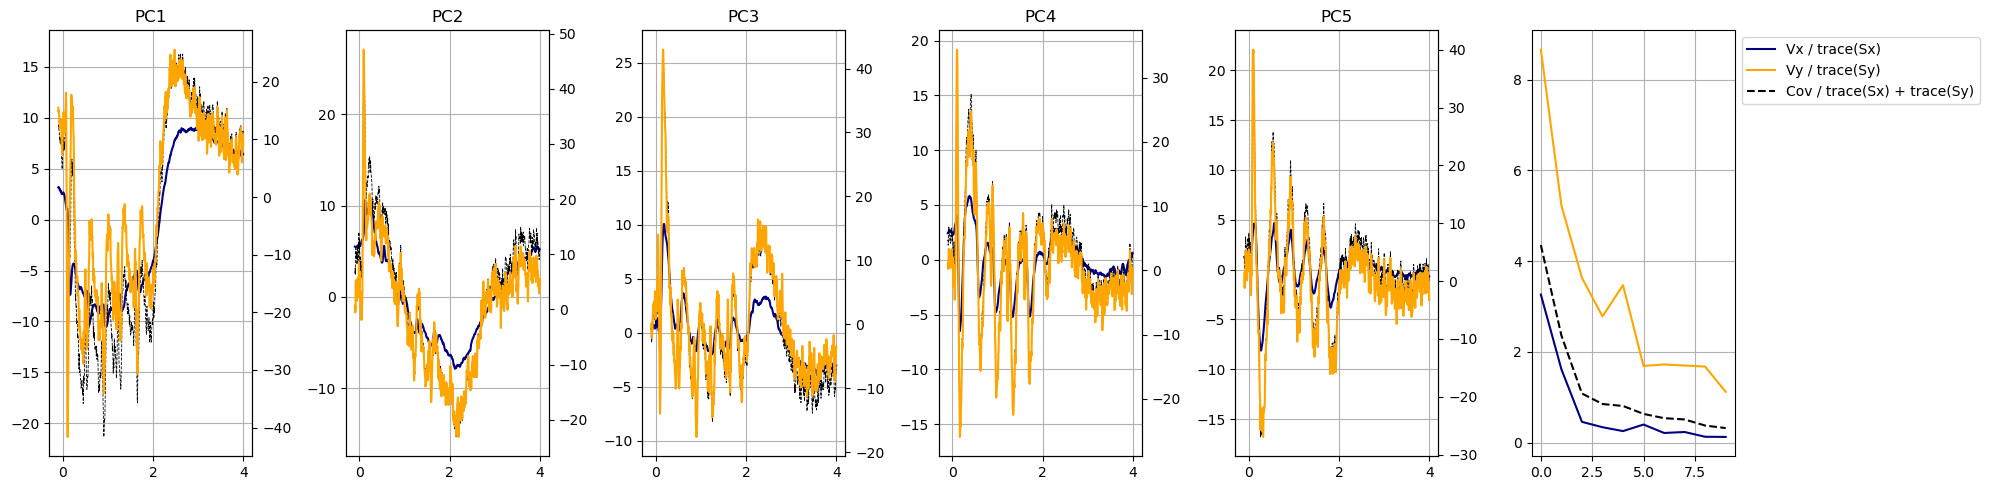

In [17]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 5))

for pc in range(5) :
    ax[pc].plot(time_ieeg, Xcca[:, pc], c='navy', label='ieeg')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, Ycca[:, pc], c='orange',  label='meg match')
    
    ax[pc].plot(time_ieeg, (Xcca[:, pc] + Ycca[:, pc])/2, c='k', label='join', ls='--', lw=0.6)

    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))


ax[-1].plot(varx_norm*100,  c='navy', label='Vx / trace(Sx)')
ax[-1].plot(vary_norm*100,  c='orange', label='Vy / trace(Sy)')
ax[-1].plot(cv_norm*100,  c='k',ls='--', label='Cov / trace(Sx) + trace(Sy)')
ax[-1].legend(bbox_to_anchor=(1, 1))
ax[-1].grid()
fig.tight_layout()

In [18]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})
    

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    
    
res_PLS= pd.DataFrame(res)

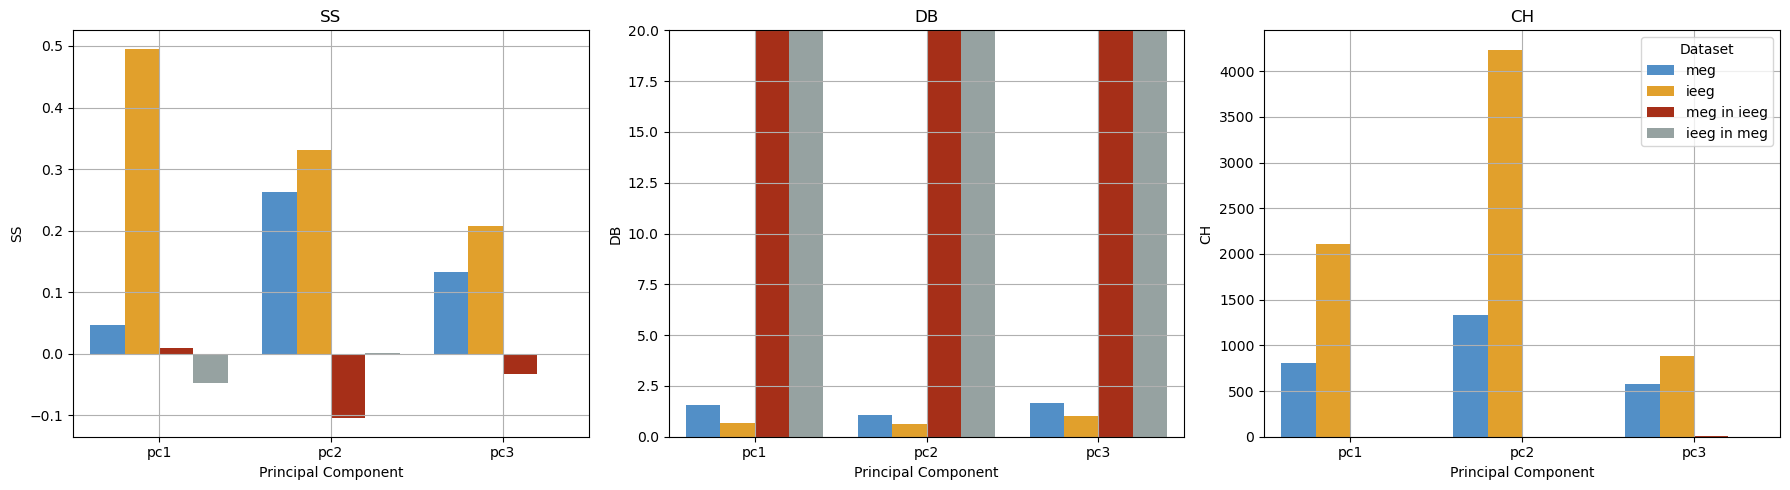

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PLS,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    if metric == 'db' : ax.set_ylim(0, 20)
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

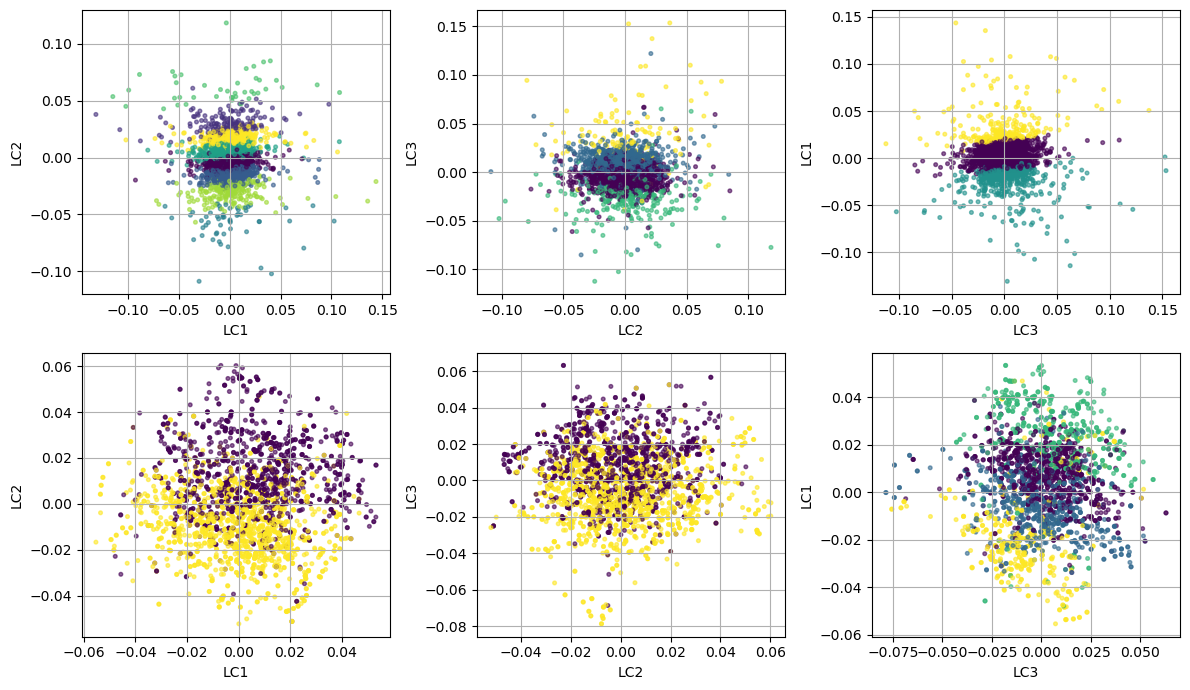

In [20]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()

thr_y = Wy
thr_x = Wx

for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(thr_x[i, :], thr_x[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(thr_y[i, :], thr_y[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

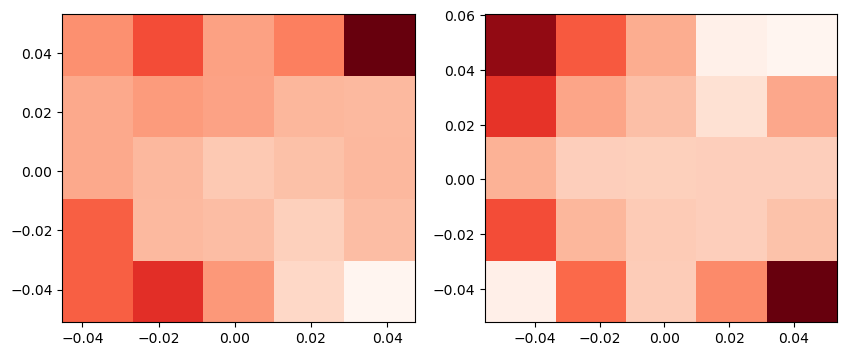

In [21]:
A= pca_matched.components_[:3, :] #cca_model.x_weights_.T[:3, :]
B= cca_model.y_weights_.T[:3, :] #pca_ieeg.components_[:3, :] #cca_model.y_weights_.T[:3, :]
distances = np.abs(A - B)[1, :]

from scipy.stats import binned_statistic_2d
mean_dist_A, x_edges_A, y_edges_A, _ = binned_statistic_2d(A[0, :],A[1, :],distances,statistic='mean',bins=5)
mean_dist_B, x_edges_B, y_edges_B, _ = binned_statistic_2d(B[0, :],B[1, :],distances,statistic='mean',bins=5)

mean_dist_A = np.nan_to_num(mean_dist_A, nan=0.0)
mean_dist_B = np.nan_to_num(mean_dist_B, nan=0.0)

fig, ax = plt.subplots( 1,2, figsize=(10, 4))
im0 = ax[0].pcolormesh(x_edges_A,y_edges_A,mean_dist_A.T,cmap='Reds')
im1 = ax[1].pcolormesh(x_edges_B,y_edges_B,mean_dist_B.T,cmap='Reds')



## Transformation for paired

In [10]:
df_label_meg  =pd.read_csv('out/labels/labels_Kmean_MEG_source_avg_pc.csv').drop(columns = ['Unnamed: 0'])
with open(out_path + '/meg_data_source.p', "rb") as f:
    data_source= pickle.load(f).mean(0).mean(0)

In [15]:
pca_meg = PCA(10)
trans_data_source = pca_meg.fit_transform(data_source.T) 

In [14]:
file=f'out/cross_models/cross_models_scale_False_avg_source/PLSSVD_model.p'
with open(file, "rb") as f:
    cca_model = pickle.load(f)

In [16]:
gradient = plt.cm.rainbow(np.linspace(0, 1, ieeg_data.shape[0]))

In [17]:
def affine_transform(A, B): 
    '''
    rotation, scaling, shear, and potentially reflection
    '''
    M = B @ np.linalg.pinv(A)
    t = (B.mean(axis=1, keepdims=True) - M @ A.mean(axis=1, keepdims=True)).ravel()
    return M, t

def compute_metrics(y_true, y_pred):
    """
    Compute metrics for arrays of shape:
        (n_features, n_samples)
    """

    rmse = np.sqrt(np.mean((y_pred - y_true)**2, axis=0))
    value_range = (np.max(y_true, axis=0) -np.min(y_true, axis=0))
    nrmse = np.divide(rmse,value_range,out=np.zeros_like(rmse),where=value_range != 0 )
  
    mape = np.abs((y_true - y_pred) / y_true)
    mape = np.where(np.isfinite(mape),mape,np.nan)
    mape = np.nanmean(mape, axis=0)
    score = 1 / (1 + mape)

    ss_res = np.sum((y_true - y_pred)**2,axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True))**2,axis=0)
    r2 = np.divide(1 - ss_res / ss_tot,1,out=np.zeros_like(ss_res),where=ss_tot != 0)

    std_true = np.std(y_true, axis=1)
    std_pred = np.std(y_pred, axis=1)
    spread_score = np.mean(np.divide(std_pred,std_true,out=np.zeros_like(std_pred),where=std_true != 0))

    cov_true = np.cov(y_true, rowvar=False)
    cov_pred = np.cov(y_pred, rowvar=False)
    if np.ndim(cov_true) == 0:
        cov_true = np.array([[cov_true]])
        cov_pred = np.array([[cov_pred]])

    cov_ratio = (np.trace(cov_pred) /np.trace(cov_true) if np.trace(cov_true) != 0 else np.nan)

    return {"RMSE": np.nanmean(rmse),
            "NRMSE": np.nanmean(nrmse),
            "MAPE_score": np.nanmean(score),
            "R2": np.nanmean(r2),
            "Spread": spread_score,
            "Covariance_ratio": cov_ratio}

def polynomial_features(A, degree=2):
    """
    A: (3, N)
    Returns Phi: (N, n_features)
    """
    x = A[0]
    y = A[1]
    z = A[2]
    if degree == 1:
        Phi = np.column_stack([np.ones(len(x)),x,y,z])
    elif degree == 2:
        Phi = np.column_stack([np.ones(len(x)),x,y,z,x**2,y**2,z**2,x*y,x*z,y*z])
    return Phi

def non_linear_tranform(A, B, degree=2):

    X = A.T
    Y = B.T

    x = X[:, 0]
    y = X[:, 1]
    z = X[:, 2]

    if degree == 2:
        Phi = np.column_stack([np.ones(len(x)),x,y,z,x**2,y**2,z**2,x*y,x*z,y*z])
    elif degree == 1:
        Phi = np.column_stack([np.ones(len(x)),x,y,z])

    # Least-squares fit
    # Phi @ coefficients ≈ Y
    coefficients, _, _, _ = np.linalg.lstsq(Phi,Y,rcond=None)
    return coefficients, Phi

In [18]:
#pca_ieeg.components_[:3, :] #pca_join_.components_[:3, :ieeg_data.shape[0]] #cca_model.x_weights_.T[:3, :]
#pca_matched.components_[:3, :]  #pca_join_.components_[:3, ieeg_data.shape[0]:]  cca_model.y_weights_.T[:3, :]
A = pca_meg.components_[:3, :]
B= cca_model.y_weights_.T[:3, :]


In [19]:
n_samples = A.shape[1]
kf = KFold(n_splits=5,shuffle=True,random_state=42)
metrics_before = []
metrics_after = []

for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
    A_train = A[:, train_idx]
    A_test  = A[:, test_idx]

    B_train = B[:, train_idx]
    B_test  = B[:, test_idx]
    Phi_train = polynomial_features(A_train,degree=2 )
    coefficients, _, _, _ = np.linalg.lstsq(Phi_train,B_train.T,rcond=None)
    Phi_test = polynomial_features(A_test,degree=2)
    B_est_test = (Phi_test @ coefficients).T
    metrics_before_fold = compute_metrics(B_test,A_test)
    metrics_after_fold = compute_metrics(B_test,B_est_test)
    metrics_before.append(metrics_before_fold)
    metrics_after.append(metrics_after_fold)

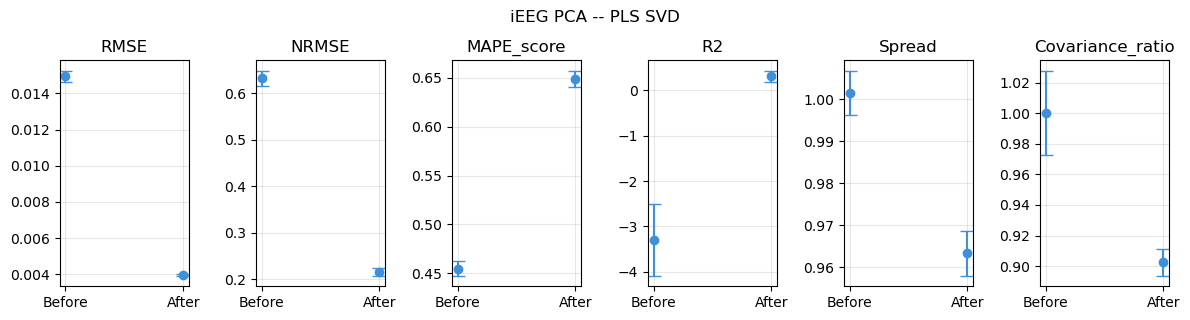

In [20]:
fig, axes = plt.subplots(1, 6,figsize=(12, 3))
metric_names = list(metrics_after[0].keys())
before_array = np.array([[metrics_before[i][name] for name in metric_names]for i in range(len(metrics_before))])
after_array = np.array([[metrics_after[i][name] for name in metric_names]for i in range(len(metrics_after))])
before_mean = np.nanmean(before_array, axis=0)
before_std  = np.nanstd(before_array, axis=0)
after_mean = np.nanmean(after_array, axis=0)
after_std  = np.nanstd(after_array, axis=0)

for i, name in enumerate(metric_names):
    ax = axes[i]
    means = [before_mean[i],after_mean[i]]
    stds = [before_std[i],after_std[i]]
    ax.errorbar([0, 1],means,yerr=stds,fmt='o',capsize=5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before", "After"])
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.tight_layout()

fig.suptitle('iEEG PCA -- PLS SVD', y=1.05)
plt.show()

Before Total variance ratio: 1.0000000000000004
Before spread score 1.1728123546604305
Before r2 [ 0.94128901 -2.58566068  0.64153639]
Before MAPE [0.41345259 0.12416181 0.21709643]
Before NRMSE [0.03704558 0.29745691 0.09969688]
After Total variance ratio: 0.902540754861243
After spread score 0.9921789240118523
After r2 [0.97928985 0.9112322  0.89405219]
After MAPE [0.44925695 0.33796221 0.3226886 ]
After NRMSE [0.02200231 0.0468023  0.05420072]


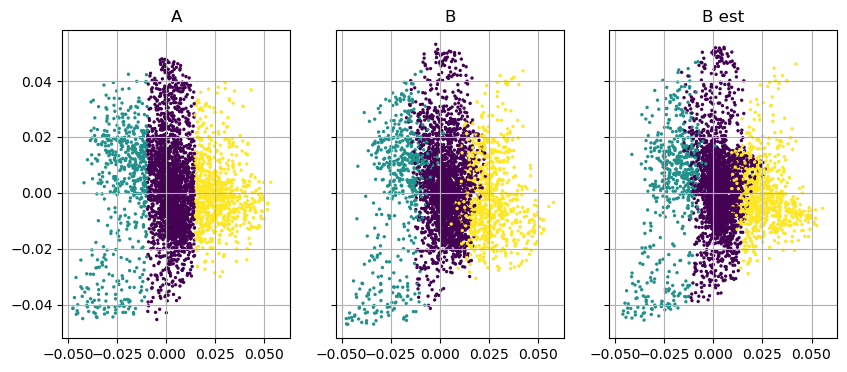

In [23]:
coefficients, Phi =  non_linear_tranform(A, B, degree=2)
B_est = (Phi @ coefficients).T
residual = B_est - B
residual_pre = A - B

cov_B = np.cov(B, rowvar=False)
cov_B_est = np.cov(B_est, rowvar=False)
cov_A = np.cov(A, rowvar=False)

rmse = np.sqrt(np.mean((A - B)**2, axis=1))
nrmse = rmse / (np.max(B, axis=1) - np.min(B, axis=1))
mape = np.mean(np.abs((B - A) / B), axis=1)
score = 1 / (1 + mape)
ss_res = np.sum((B - A)**2, axis=1)
ss_tot = np.sum((B - np.mean(B, axis=1, keepdims=True))**2, axis=1)
r2 = 1 - ss_res / ss_tot
spread_score = np.mean(np.std(A, axis=0) / np.std(B, axis=0))
cov_ratio = np.trace(cov_A) / np.trace(cov_B)
print("Before Total variance ratio:", cov_ratio)
print('Before spread score', spread_score)
print('Before r2', r2)
print('Before MAPE', score)
print('Before NRMSE', nrmse)


rmse = np.sqrt(np.mean((B_est - B)**2, axis=1))
nrmse = rmse / (np.max(B, axis=1) - np.min(B, axis=1))
mape = np.mean(np.abs((B - B_est) / B), axis=1)
score = 1 / (1 + mape)
ss_res = np.sum((B - B_est)**2, axis=1)
ss_tot = np.sum((B - np.mean(B, axis=1, keepdims=True))**2, axis=1)
r2 = 1 - ss_res / ss_tot
spread_score = np.mean(np.std(B_est, axis=0) / np.std(B, axis=0))
cov_ratio = np.trace(cov_B_est) / np.trace(cov_B)
print("After Total variance ratio:", cov_ratio)
print('After spread score', spread_score)
print('After r2', r2)
print('After MAPE', score)
print('After NRMSE', nrmse)

fig, ax=plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 4)) 

ax[0].set_title('A')
ax[1].set_title('B')
ax[2].set_title('B est')
ax[0].scatter(A[0, :], A[2, :],  s=2, c=df_label_meg[f'meg_pc0'].values)
ax[1].scatter(B[ 0, :], B[2, :],  s=2, c=df_label_meg[f'meg_pc0'].values)
ax[2].scatter(B_est[0, :], B_est[2, :], s=2, c=df_label_meg[f'meg_pc0'].values)

for a in ax: 
    a.grid()

[0.00242001 0.00514516 0.00551406]


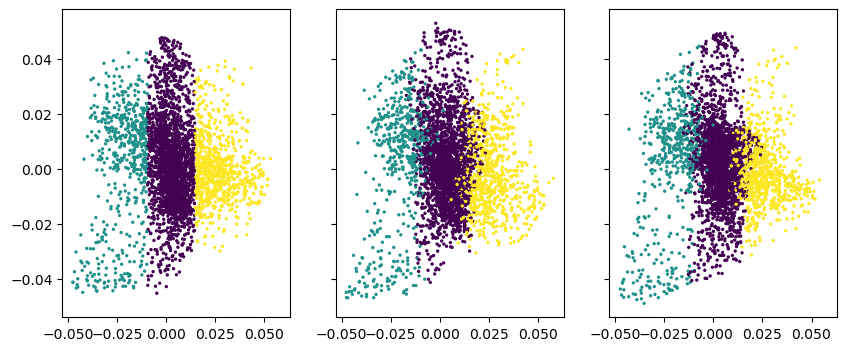

In [28]:
R, t = affine_transform(A, B)
B_est = (R @ A).T + t

fig, ax=plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 4))
ax[0].scatter(A[0, :], A[2, :],  s=2, c=df_label_meg[f'meg_pc0'].values)
ax[1].scatter(B[ 0, :], B[2, :],  s=2, c=df_label_meg[f'meg_pc0'].values)
ax[2].scatter(B_est.T[0, :], B_est.T[2, :], s=2, c=df_label_meg[f'meg_pc0'].values)

In [31]:
# analysis 
M = R
det_R = np.linalg.det(M)
U, S, Vt = np.linalg.svd(M)
R_rotation = U @ Vt
S_deformation = Vt.T @ np.diag(S) @ Vt

print("Transformation matrix:")
print(M)

print("\nTranslation:")
print(t)

print("\nDeterminant:")
print(det_R)
if det_R > 0:
    print("No reflection: orientation preserved")
elif det_R < 0:
    print("Reflection detected")
else:
    print("Singular transformation")

print("Scaling (%):",(S - 1) * 100)

print("\nRotation:")
cos_theta = (np.trace(R_rotation) - 1) / 2
cos_theta = np.clip(cos_theta,-1,1)
theta = np.arccos(cos_theta)
print("Rotation angle:",np.degrees(theta),"degrees")

print("\nDeformation:")
print(S_deformation)


Transformation matrix:
[[ 0.97282453 -0.13588418  0.11913459]
 [-0.14776239 -0.78986116  0.50943975]
 [-0.0371224   0.46089956  0.82253682]]

Translation:
[ 0.00017719 -0.00038965  0.00063069]

Determinant:
-0.8860062846708192
Reflection detected

Singular values:
Scaling (%): [-0.46871915 -2.57877762 -8.62579005]

Rotation:
Rotation angle: 90.1692936074057 degrees

Deformation:
[[ 0.98452272 -0.01702038  0.00496828]
 [-0.01702038  0.92415023 -0.020742  ]
 [ 0.00496828 -0.020742    0.97459418]]


## Transformation for unpaired

In [243]:
# A and B are paired in indices
# Once paired they A can be transformed to B -- A_transofrm = f(B[indices])
A= cca_model.x_weights_.T[:3, :]
B= cca_model.y_weights_.T[:3, :]

In [239]:
def affine_registration(A,B,max_iterations=100,tolerance=1e-10,lambda_cov=10.0,lambda_mean=1.0,):
    """
    Register two unpaired 3D point clouds using an affine transformation.
    Finds:B ~= M @ A + t
    Objective:
        symmetric Chamfer distance
        + lambda_cov * covariance mismatch
        + lambda_mean * mean mismatch
    A, B:shape (3, N)
    Returns:M, t, indices, error
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    mean_B = np.mean(B, axis=1)
    B_centered = B - mean_B[:, None]
    cov_B = np.cov(B_centered, rowvar=True)
    cov_scale = np.linalg.norm(cov_B, ord="fro")**2
    if cov_scale < 1e-12:
        cov_scale = 1.0

    M = np.eye(3)
    t = mean_B - M @ np.mean(A, axis=1)
    previous_error = np.inf
    tree_B = cKDTree(B.T)
    for iteration in range(max_iterations):
        A_transformed = M @ A + t[:, None]
        distances_AB, indices = tree_B.query(A_transformed.T)
        B_matched = B[:, indices]
        def objective(params):
            M_candidate = params[:9].reshape(3, 3)
            t_candidate = params[9:12]
            X = M_candidate @ A + t_candidate[:, None]
            point_error = np.mean(np.sum((X - B_matched)**2, axis=0))
            mean_X = np.mean(X, axis=1)
            mean_error = np.sum((mean_X - mean_B)**2)
            X_centered = X - mean_X[:, None]
            cov_X = np.cov(X_centered,rowvar=True)
            cov_error = (np.linalg.norm(cov_X - cov_B,ord="fro")**2/ cov_scale)
            return (point_error+ lambda_cov * cov_error+ lambda_mean * mean_error)

        params0 = np.concatenate([M.ravel(),t])
        result = minimize(objective,params0,method="L-BFGS-B",options={"maxiter": 100,"ftol": 1e-10,"gtol": 1e-6,})
        params = result.x
        M_new = params[:9].reshape(3, 3)
        t_new = params[9:12]
        A_new = M_new @ A + t_new[:, None]
        tree_A = cKDTree(A_new.T)
        d_AB, indices_AB = tree_B.query(A_new.T)
        d_BA, _ = tree_A.query(B.T)
        chamfer = (np.mean(d_AB**2)+ np.mean(d_BA**2)) / 2
        rmse = np.sqrt(chamfer)
        if abs(previous_error - rmse) < tolerance:
            M = M_new
            t = t_new
            print(f"Converged at iteration {iteration + 1}")
            break

        M = M_new
        t = t_new
        previous_error = rmse

    A_final = M @ A + t[:, None]
    distances, indices = tree_B.query(A_final.T)
    rmse = np.sqrt(np.mean(distances**2))
    return M, t, indices, rmse

def polynomial_registration(A,B,max_iterations=500,tolerance=1e-20,lambda_cov=10.0,lambda_mean=1.0,):
    """
    Register two unpaired 3D point clouds using a quadratic polynomial transformation.
    Finds:B ~= polynomial(A)
    Objective:
        symmetric Chamfer distance
        + lambda_cov * covariance mismatch
        + lambda_mean * mean mismatch
    A, B:shape (3, N)
    Returns:coefficients, indices, error
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    mean_B = np.mean(B, axis=1)
    B_centered = B - mean_B[:, None]
    cov_B = np.cov(B_centered, rowvar=True)
    cov_scale = np.linalg.norm(cov_B, ord="fro")**2
    if cov_scale < 1e-12:
        cov_scale = 1.0

    # ---------------------------------------------------------
    # Polynomial basis
    # ---------------------------------------------------------

    def polynomial_features(X):

        x = X[0]
        y = X[1]
        z = X[2]

        return np.vstack([
            np.ones(X.shape[1]),
            x,
            y,
            z,
            x**2,
            y**2,
            z**2,
            x*y,
            x*z,
            y*z,
        ])

    # ---------------------------------------------------------
    # Initial transformation
    # ---------------------------------------------------------

    mean_A = np.mean(A, axis=1)

    # Start with identity transformation plus translation.
    coefficients = np.zeros((3, 10))
    coefficients[:, 0] = mean_B - mean_A
    coefficients[:, 1] = 1.0
    coefficients[:, 2] = 1.0
    coefficients[:, 3] = 1.0

    previous_error = np.inf

    tree_B = cKDTree(B.T)

    # ---------------------------------------------------------
    # ICP
    # ---------------------------------------------------------

    for iteration in range(max_iterations):

        # Current transformed A
        Phi_A = polynomial_features(A)
        A_transformed = coefficients @ Phi_A

        # -----------------------------------------------------
        # Find A -> B correspondences
        # -----------------------------------------------------

        distances_AB, indices = tree_B.query(
            A_transformed.T
        )

        B_matched = B[:, indices]

        # -----------------------------------------------------
        # Optimize polynomial transformation
        # -----------------------------------------------------

        def objective(params):

            coefficients_candidate = params.reshape(3, 10)

            X = coefficients_candidate @ Phi_A

            # -------------------------------------------------
            # 1. Point-to-point error
            # -------------------------------------------------

            point_error = np.mean(
                np.sum((X - B_matched)**2, axis=0)
            )

            # -------------------------------------------------
            # 2. Mean preservation
            # -------------------------------------------------

            mean_X = np.mean(X, axis=1)

            mean_error = np.sum(
                (mean_X - mean_B)**2
            )

            # -------------------------------------------------
            # 3. Covariance preservation
            # -------------------------------------------------

            X_centered = X - mean_X[:, None]

            cov_X = np.cov(
                X_centered,
                rowvar=True
            )

            cov_error = (
                np.linalg.norm(
                    cov_X - cov_B,
                    ord="fro"
                )**2
                / cov_scale
            )

            return (
                point_error
                + lambda_cov * cov_error
                + lambda_mean * mean_error
            )

        params0 = coefficients.ravel()

        result = minimize(
            objective,
            params0,
            method="L-BFGS-B",
            options={
                "maxiter": 100,
                "ftol": 1e-10,
                "gtol": 1e-6,
            }
        )

        params = result.x

        coefficients_new = params.reshape(3, 10)

        # -----------------------------------------------------
        # New transformed cloud
        # -----------------------------------------------------

        A_new = coefficients_new @ Phi_A

        # -----------------------------------------------------
        # Symmetric Chamfer error
        # -----------------------------------------------------

        tree_A = cKDTree(A_new.T)

        d_AB, indices_AB = tree_B.query(A_new.T)
        d_BA, _ = tree_A.query(B.T)

        chamfer = (
            np.mean(d_AB**2)
            + np.mean(d_BA**2)
        ) / 2

        rmse = np.sqrt(chamfer)

        # -----------------------------------------------------
        # Check convergence
        # -----------------------------------------------------

        if abs(previous_error - rmse) < tolerance:

            coefficients = coefficients_new

            print(
                f"Converged at iteration {iteration + 1}"
            )

            break

        coefficients = coefficients_new
        previous_error = rmse

    Phi_A = polynomial_features(A)

    A_final = coefficients @ Phi_A

    distances, indices = tree_B.query(A_final.T)

    rmse = np.sqrt(np.mean(distances**2))

    return coefficients, indices, rmse

def polynomial_features(X):

    x = X[0]
    y = X[1]
    z = X[2]

    return np.vstack([
        np.ones(X.shape[1]),
        x,
        y,
        z,
        x**2,
        y**2,
        z**2,
        x*y,
        x*z,
        y*z,
    ])

In [230]:
M, t, indices, rmse = affine_registration(A, B)

U, S, Vt = np.linalg.svd(M)
R = U @ Vt
stretch_tensor = Vt.T @ np.diag(S) @ Vt
print("Rotation:")
print(R)
print("\nDeformation:")
print(stretch_tensor)
det_R = np.linalg.det(R)
if det_R > 0:
    cos_theta = (np.trace(R) - 1) / 2
    cos_theta = np.clip(cos_theta, -1, 1)
    theta = np.arccos(cos_theta)

    print("Rotation angle:", np.degrees(theta), "degrees")
else:
    print("R contains a reflection; rotation angle is not valid.")

A_transformed = M @ A + t[:, None]


Rotation:
[[ 0.99872535 -0.04923105 -0.01113466]
 [ 0.0490412   0.99865671 -0.01672558]
 [ 0.01194312  0.01615821  0.99979812]]

Deformation:
[[ 9.90655305e-01 -7.48469652e-04 -1.59147915e-04]
 [-7.48469652e-04  1.00030203e+00 -2.49184114e-04]
 [-1.59147915e-04 -2.49184114e-04  1.00014398e+00]]
Rotation angle: 3.0428812223722765 degrees


In [240]:
A= cca_model.x_weights_.T[:3, :]
B= cca_model.y_weights_.T[:3, :]
coefficients, indices, rmse = polynomial_registration(A, B)
A_transformed = coefficients @ polynomial_features(A)

Mean NN distance: 0.023903165774826263
Median NN distance: 0.01913326120580389


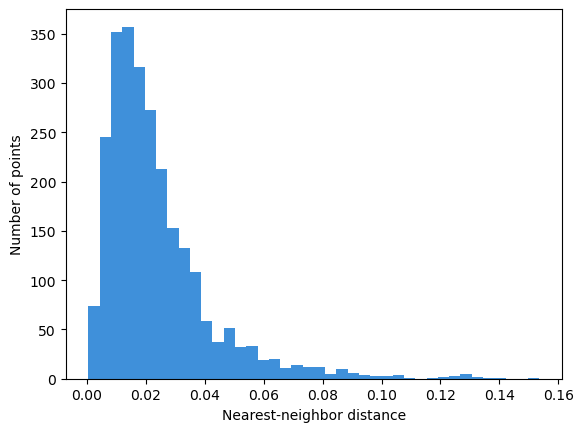

In [242]:
nn_distance = np.linalg.norm(A - B[:, indices],axis=0)
print("Mean NN distance:", nn_distance.mean())
print("Median NN distance:", np.median(nn_distance))
plt.hist(nn_distance, bins=40)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Number of points")

plt.show()

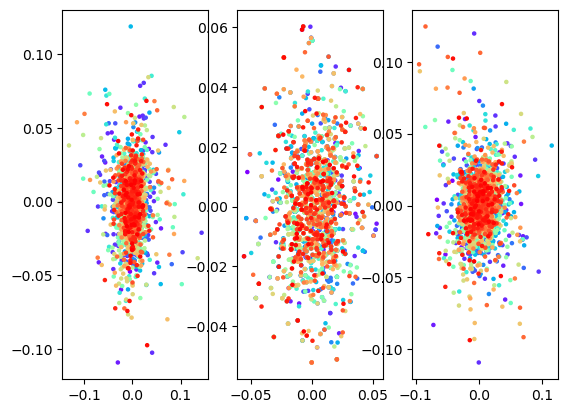

In [249]:

fig, ax= plt.subplots(1, 3)
ax[0].scatter(A[0], A[1],s=5, c=gradient) #df_label['ieeg_pc0'])
ax[1].scatter(B[0, indices],B[1, indices],s=5, c=gradient) #c=df_label.loc[indices, 'meg_pc0'])
ax[2].scatter(A_transformed[0],A_transformed[1],s=5, c=gradient) #c=df_label['meg_pc0'])